# Badanie korelacji między panelami PV i drzewami

> comments and conclusions no longer correspond to the results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm

## Wczytanie danych

In [2]:
pv_df = pd.read_csv('pv_areas_125_3.csv', header= None, names=['image', 'pv_area_share'])
tree_df = pd.read_csv('tree_areas125.csv')
pv_df.head()

,image,pv_area_share
0,/users/project1/pt01299/imagery125_640px/2019_...,0.000146
1,/users/project1/pt01299/imagery125_640px/2019_...,0.002827
2,/users/project1/pt01299/imagery125_640px/2019_...,0.003081
3,/users/project1/pt01299/imagery125_640px/2019_...,0.002866
4,/users/project1/pt01299/imagery125_640px/2019_...,0.002407


In [3]:
pv_df['year'] = pv_df['image'].str.extract(r'/(2019|202[0-4])')
pv_df['year'] = pv_df['year'].astype(int)

# pv_df['id'] = pv_df['image'].str.split('/').str[-1]
# pv_df['id'] = pv_df['id'].str.replace(r'(2019|202[0-4])_', '', regex=True).str.replace('.jpg', '', regex=False)
pv_df['godlo'] = pv_df['image'].str.split('N').str[-1]
pv_df['godlo'] = pv_df['godlo'].replace('.jpg', '', regex=False)
pv_df.drop('image', axis=1,  inplace=True)
pv_df.head()

,pv_area_share,year,godlo
0,0.000146,2019,-34-62-A-a-1-1_105.jpg
1,0.002827,2019,-34-62-A-a-1-1_114.jpg
2,0.003081,2019,-34-62-A-a-1-1_123.jpg
3,0.002866,2019,-34-62-A-a-1-1_132.jpg
4,0.002407,2019,-34-62-A-a-1-1_134.jpg


In [4]:
tree_df.head()

,image,tree_area_share,tree_area_percent
0,2020_73642_915286_N-34-50-C-c-3-1_88.jpg,0.040977,4.097656
1,2021_75127_1070337_N-34-62-A-b-1-3_54.jpg,0.196172,19.617188
2,2022_76176_1074747_N-34-49-D-d-2-3_172.jpg,0.005664,0.566406
3,2024_81010_1322912_N-34-62-A-b-3-1_157.jpg,0.000000,0.000000
4,2023_78971_1261437_N-34-50-D-c-3-2_65.jpg,0.000000,0.000000


In [5]:
tree_df['year'] = tree_df['image'].str.extract(r'^(2019|202[0-4])')
tree_df['year'] = tree_df['year'].astype(int)

# tree_df['id'] = tree_df['image'].str.replace(r'^(2019|202[0-4])_', '', regex=True).str.replace('.jpg', '', regex=False)
tree_df['godlo'] = tree_df['image'].str.split('N').str[-1]
tree_df['godlo'] = tree_df['godlo'].replace('.jpg', '', regex=False)
tree_df.drop(['image','tree_area_percent'], axis=1,  inplace=True)

tree_df.head()

,tree_area_share,year,godlo
0,0.040977,2020,-34-50-C-c-3-1_88.jpg
1,0.196172,2021,-34-62-A-b-1-3_54.jpg
2,0.005664,2022,-34-49-D-d-2-3_172.jpg
3,0.000000,2024,-34-62-A-b-3-1_157.jpg
4,0.000000,2023,-34-50-D-c-3-2_65.jpg


## Czyszczenie i transformacja danych

In [6]:
# tree_df = tree_df.dropna(subset=['id', 'year', 'tree_area_share'])
# pv_df = pv_df.dropna(subset=['id', 'year', 'pv_area_share'])
tree_df = tree_df.dropna(subset=['godlo', 'year', 'tree_area_share'])
pv_df = pv_df.dropna(subset=['godlo', 'year', 'pv_area_share'])
tree_df = tree_df[(tree_df['tree_area_share'] >= 0) & (tree_df['tree_area_share'] <= 1)]
pv_df = pv_df[(pv_df['pv_area_share'] >= 0) & (pv_df['pv_area_share'] <= 1)]

In [7]:
df_merged = pd.merge(
    tree_df,
    pv_df,
    on=['godlo', 'year'],
    how='outer'
)

In [8]:
df_merged.isna().sum()

tree_area_share         0
year                    0
godlo                   0
pv_area_share      119732
dtype: int64

In [9]:
df_merged['pv_area_share'] = df_merged['pv_area_share'].fillna(0)

In [10]:
# df_merged['id'] = df_merged['id'].str.extract(r'(N-\d+-\d+-[A-Z]-[a-z]-\d-\d_tile_r+\d+_c+\d+)')

In [11]:
df_merged = df_merged.sort_values(['godlo', 'year'])
df_merged.head()

,tree_area_share,year,godlo,pv_area_share
0,0.998359,2019,-34-49-B-c-4-4_0.jpg,0.0
1,1.000000,2020,-34-49-B-c-4-4_0.jpg,0.0
2,0.988398,2021,-34-49-B-c-4-4_0.jpg,0.0
3,0.999336,2022,-34-49-B-c-4-4_0.jpg,0.0
4,0.999883,2023,-34-49-B-c-4-4_0.jpg,0.0


In [12]:
df_merged.isna().sum()

tree_area_share    0
year               0
godlo              0
pv_area_share      0
dtype: int64

In [13]:
df_merged['year'].value_counts().sort_index()

year
2019    24375
2020    24375
2021    24375
2022    24375
2023    24375
2024    24375
Name: count, dtype: int64

In [14]:
df_agg = (
    df_merged
    .groupby(['godlo', 'year'], as_index=False)
    .agg(
        tree_area_share=('tree_area_share', 'mean'),
        pv_area_share=('pv_area_share', 'mean')
    )
)

In [15]:
df_agg['year'].value_counts().sort_index()

year
2019    24375
2020    24375
2021    24375
2022    24375
2023    24375
2024    24375
Name: count, dtype: int64

In [16]:
df_agg.isna().sum()

godlo              0
year               0
tree_area_share    0
pv_area_share      0
dtype: int64

In [17]:
df_agg.groupby('godlo')['year'].nunique().describe()

count    24375.0
mean         6.0
std          0.0
min          6.0
25%          6.0
50%          6.0
75%          6.0
max          6.0
Name: year, dtype: float64

In [18]:
df_full = df_agg.copy()
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146250 entries, 0 to 146249
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   godlo            146250 non-null  object 
 1   year             146250 non-null  int64  
 2   tree_area_share  146250 non-null  float64
 3   pv_area_share    146250 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 4.5+ MB


In [19]:
# df_full['area_id'] = df_full['id'].str.extract(r'(N-\d+-\d+-[A-Z]-[a-z]-\d-\d)')
df_full['area_id'] = df_full['godlo']
df_full.head()

,godlo,year,tree_area_share,pv_area_share,area_id
0,-34-49-B-c-4-4_0.jpg,2019,0.998359,0.0,-34-49-B-c-4-4_0.jpg
1,-34-49-B-c-4-4_0.jpg,2020,1.000000,0.0,-34-49-B-c-4-4_0.jpg
2,-34-49-B-c-4-4_0.jpg,2021,0.988398,0.0,-34-49-B-c-4-4_0.jpg
3,-34-49-B-c-4-4_0.jpg,2022,0.999336,0.0,-34-49-B-c-4-4_0.jpg
4,-34-49-B-c-4-4_0.jpg,2023,0.999883,0.0,-34-49-B-c-4-4_0.jpg


In [20]:
df_full[['tree_area_share', 'pv_area_share']].describe()

,tree_area_share,pv_area_share
count,146250.000000,146250.000000
mean,0.299332,0.017133
std,0.368474,0.108758
min,0.000000,0.000000
25%,0.002070,0.000000
50%,0.104258,0.000000
75%,0.553633,0.000000
max,1.000000,0.998369


In [21]:
df_full['year'].value_counts().sort_index()

year
2019    24375
2020    24375
2021    24375
2022    24375
2023    24375
2024    24375
Name: count, dtype: int64

In [22]:
df_full['pixel_size'] = np.where(
    df_full['year'].isin([2019, 2020, 2023]),
    0.25,
    0.5
)
df_full['pixel_area'] = df_full['pixel_size'] ** 2

In [23]:
df_full[['year', 'pixel_size', 'pixel_area']].drop_duplicates().sort_values('year')

,year,pixel_size,pixel_area
0,2019,0.25,0.0625
1,2020,0.25,0.0625
2,2021,0.50,0.2500
3,2022,0.50,0.2500
4,2023,0.25,0.0625
5,2024,0.50,0.2500


In [24]:
df = (
    df_full
    .groupby(['area_id', 'year'])
    .apply(lambda x: pd.Series({
        'tree_area_share': (x['tree_area_share'] * x['pixel_area']).sum()
                            / x['pixel_area'].sum(),
        'pv_area_share': (x['pv_area_share'] * x['pixel_area']).sum()
                          / x['pixel_area'].sum()
    }))
    .reset_index()
)
df['year'].value_counts().sort_index()

C:\Users\admin\AppData\Local\Temp\ipykernel_25416\3708435897.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


year
2019    24375
2020    24375
2021    24375
2022    24375
2023    24375
2024    24375
Name: count, dtype: int64

In [25]:
df_area = df.sort_values(['area_id', 'year'])

In [26]:
df.groupby('area_id')['year'].nunique().describe()

count    24375.0
mean         6.0
std          0.0
min          6.0
25%          6.0
50%          6.0
75%          6.0
max          6.0
Name: year, dtype: float64

In [27]:
df.head(6)

,area_id,year,tree_area_share,pv_area_share
0,-34-49-B-c-4-4_0.jpg,2019,0.998359,0.0
1,-34-49-B-c-4-4_0.jpg,2020,1.000000,0.0
2,-34-49-B-c-4-4_0.jpg,2021,0.988398,0.0
3,-34-49-B-c-4-4_0.jpg,2022,0.999336,0.0
4,-34-49-B-c-4-4_0.jpg,2023,0.999883,0.0
5,-34-49-B-c-4-4_0.jpg,2024,0.997539,0.0


In [28]:
df['delta_tree'] = df.groupby('area_id')['tree_area_share'].diff()
df['delta_pv'] = df.groupby('area_id')['pv_area_share'].diff()

In [29]:
df['pv_appeared'] = (
    (df['pv_area_share'] > 0)
    & (df.groupby('area_id')['pv_area_share'].shift(1).fillna(0) == 0)
)

In [30]:
df['post_PV'] = df.groupby('area_id')['pv_appeared'].cumsum() > 0
df['have_PV'] = df.groupby('area_id')['pv_area_share'].transform('max') > 0

In [31]:
df.head(6)

,area_id,year,tree_area_share,pv_area_share,delta_tree,delta_pv,pv_appeared,post_PV,have_PV
0,-34-49-B-c-4-4_0.jpg,2019,0.998359,0.0,NaN,NaN,False,False,False
1,-34-49-B-c-4-4_0.jpg,2020,1.000000,0.0,0.001641,0.0,False,False,False
2,-34-49-B-c-4-4_0.jpg,2021,0.988398,0.0,-0.011602,0.0,False,False,False
3,-34-49-B-c-4-4_0.jpg,2022,0.999336,0.0,0.010938,0.0,False,False,False
4,-34-49-B-c-4-4_0.jpg,2023,0.999883,0.0,0.000547,0.0,False,False,False
5,-34-49-B-c-4-4_0.jpg,2024,0.997539,0.0,-0.002344,0.0,False,False,False


## Analiza korelacji

### Mickiewicz

In [32]:
mck = df[df['area_id'].str.startswith('-34-50-C-c-4-4')]
mck

,area_id,year,tree_area_share,pv_area_share,delta_tree,delta_pv,pv_appeared,post_PV,have_PV
90090,-34-50-C-c-4-4_0.jpg,2019,0.094805,0.000000,NaN,NaN,False,False,True
90091,-34-50-C-c-4-4_0.jpg,2020,0.033516,0.085444,-0.061289,0.085444,True,True,True
90092,-34-50-C-c-4-4_0.jpg,2021,0.093594,0.000000,0.060078,-0.085444,False,True,True
90093,-34-50-C-c-4-4_0.jpg,2022,0.055352,0.010901,-0.038242,0.010901,True,True,True
90094,-34-50-C-c-4-4_0.jpg,2023,0.052031,0.000000,-0.003320,-0.010901,False,True,True
...,...,...,...,...,...,...,...,...,...
91255,-34-50-C-c-4-4_99.jpg,2020,0.045625,0.000000,-0.180586,-0.000432,False,True,True
91256,-34-50-C-c-4-4_99.jpg,2021,0.318320,0.000869,0.272695,0.000869,True,True,True
91257,-34-50-C-c-4-4_99.jpg,2022,0.135859,0.003403,-0.182461,0.002534,False,True,True
91258,-34-50-C-c-4-4_99.jpg,2023,0.077461,0.000000,-0.058398,-0.003403,False,True,True


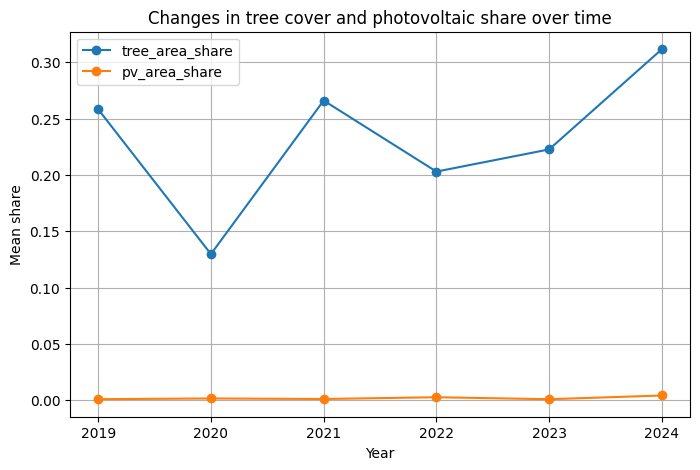

In [33]:
mck.groupby('year')[['tree_area_share', 'pv_area_share']].mean().plot(figsize=(8,5),
    title="Changes in tree cover and photovoltaic share over time",marker="o")
plt.xlabel("Year")
plt.ylabel("Mean share")
plt.grid(True)
plt.show()

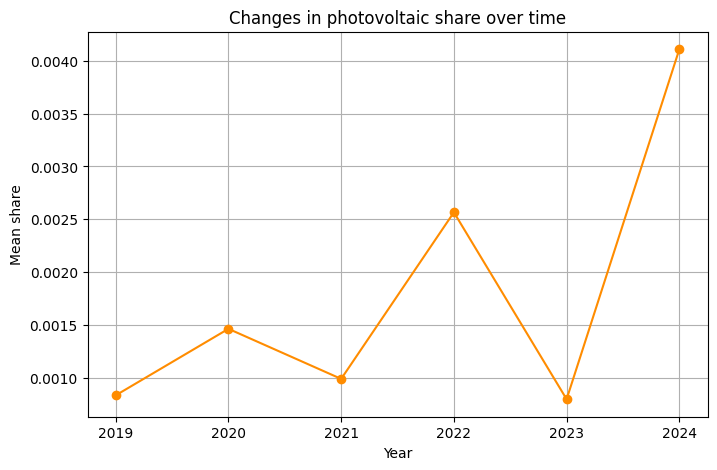

In [34]:
mck.groupby('year')['pv_area_share'].mean().plot(figsize=(8,5),
    title="Changes in photovoltaic share over time", marker="o",color='darkorange')
plt.xlabel("Year")
plt.ylabel("Mean share")
plt.grid(True)
plt.show()

### Mickiewicz 23

In [35]:
mck = df[df['area_id'].str.startswith('-34-50-C-c-4-4_23')]
mck

,area_id,year,tree_area_share,pv_area_share,delta_tree,delta_pv,pv_appeared,post_PV,have_PV
90756,-34-50-C-c-4-4_23.jpg,2019,0.507266,0.000000,NaN,NaN,False,False,True
90757,-34-50-C-c-4-4_23.jpg,2020,0.239609,0.000000,-0.267656,0.000000,False,False,True
90758,-34-50-C-c-4-4_23.jpg,2021,0.530078,0.000000,0.290469,0.000000,False,False,True
90759,-34-50-C-c-4-4_23.jpg,2022,0.191133,0.004390,-0.338945,0.004390,True,True,True
90760,-34-50-C-c-4-4_23.jpg,2023,0.350352,0.001174,0.159219,-0.003215,False,True,True
90761,-34-50-C-c-4-4_23.jpg,2024,0.518945,0.013835,0.168594,0.012661,False,True,True


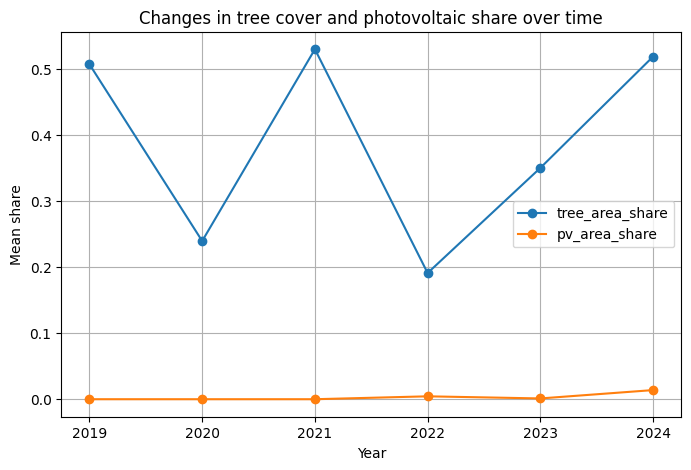

In [36]:
mck.groupby('year')[['tree_area_share', 'pv_area_share']].mean().plot(figsize=(8,5),
    title="Changes in tree cover and photovoltaic share over time",marker="o")
plt.xlabel("Year")
plt.ylabel("Mean share")
plt.grid(True)
plt.show()

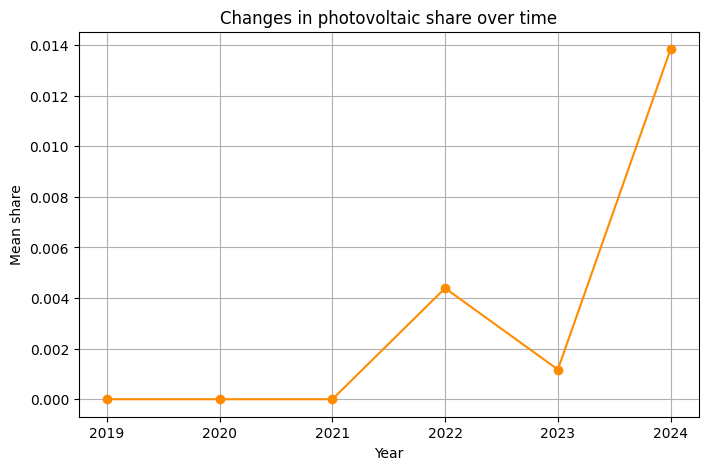

In [37]:
mck.groupby('year')['pv_area_share'].mean().plot(figsize=(8,5),
    title="Changes in photovoltaic share over time", marker="o",color='darkorange')
plt.xlabel("Year")
plt.ylabel("Mean share")
plt.grid(True)
plt.show()

### general

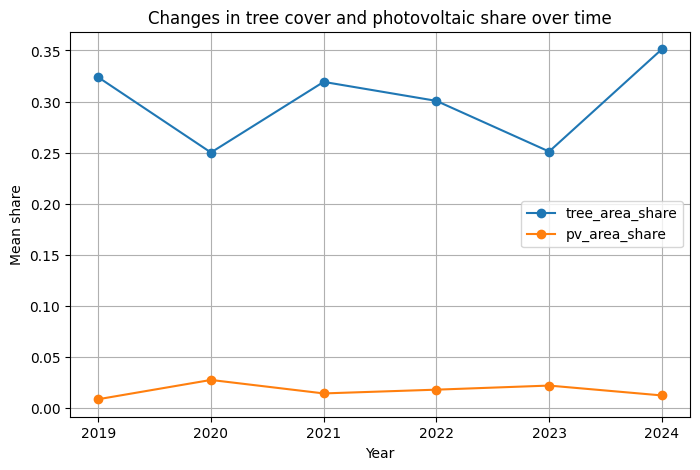

In [38]:
df.groupby('year')[['tree_area_share', 'pv_area_share']].mean().plot(figsize=(8,5),
    title="Changes in tree cover and photovoltaic share over time",marker="o")
plt.xlabel("Year")
plt.ylabel("Mean share")
plt.grid(True)
plt.show()

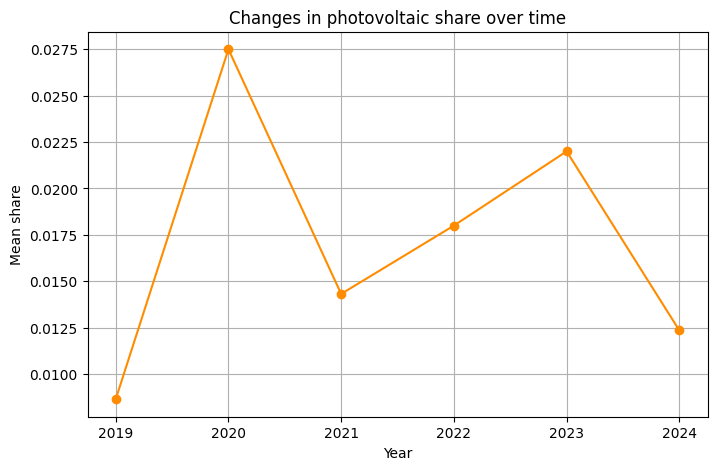

In [39]:
df.groupby('year')['pv_area_share'].mean().plot(figsize=(8,5),
    title="Changes in photovoltaic share over time", marker="o",color='darkorange')
plt.xlabel("Year")
plt.ylabel("Mean share")
plt.grid(True)
plt.show()

Średni udział instalacji fotowoltaicznych utrzymuje się na niskim poziomie we wszystkich latach, nastomiast zadrzewienie wykazuje większą zmienność z roku na rok. Wykresy nie wskazują na silną ani spójną zależność między tymi dwiema zmiennymi

#### Before-after

In [40]:
before_mean = df.loc[df['have_PV'] & (~df['post_PV']), 'delta_tree'].mean()
after_mean  = df.loc[df['have_PV'] & (df['post_PV']),  'delta_tree'].mean()

print('Średnia zmiana drzew BEFORE:', before_mean)
print('Średnia zmiana drzew AFTER :', after_mean)

Średnia zmiana drzew BEFORE: -0.011071482364445143
Średnia zmiana drzew AFTER : 0.01233687312456641


W większości analizowanych obszarów panele istnieją już w pierwszym roku danych, więc analiza before-after/DiD nie jest możliwa.

#### Analiza zależności zmian

Czy w latach, gdy bardziej przybywa paneli, drzewa zwykle bardziej znikają?

In [41]:
df[['delta_tree', 'delta_pv']].corr()

,delta_tree,delta_pv
delta_tree,1.000000,-0.016611
delta_pv,-0.016611,1.000000


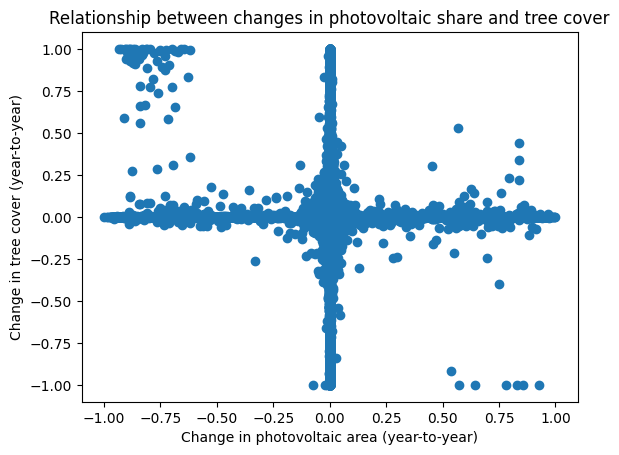

In [42]:
plt.scatter(df['delta_pv'], df['delta_tree'])
plt.xlabel('Change in photovoltaic area (year-to-year)')
plt.ylabel('Change in tree cover (year-to-year)')
plt.title('Relationship between changes in photovoltaic share and tree cover')
plt.show()

Wynik -0.06 oznacza, że gdy PV rośnie, zadrzewienie lekko maleje. Jest to jednak mała wartość (bliska 0), co wskazuje na bardzo małą zależność (prawie brak).

In [43]:
mask = df[["delta_pv", "delta_tree"]].dropna().index
r, p = pearsonr(df.loc[mask, "delta_pv"], df.loc[mask, "delta_tree"])
r, p

(np.float64(-0.016610548252946684), np.float64(6.663892052737983e-09))

Wartość p>0.05 oznacza, że wynik nie jest istotny statystycznie. Nie stwierdzono istotnej statystycznie zależności pomiędzy zmianami udziału instalacji fotowoltaicznych a zmianami zadrzewienia.

In [44]:
X = df.loc[mask, "delta_pv"]
y = df.loc[mask, "delta_tree"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             delta_tree   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     33.64
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           6.66e-09
Time:                        01:12:54   Log-Likelihood:                 48147.
No. Observations:              121875   AIC:                        -9.629e+04
Df Residuals:                  121873   BIC:                        -9.627e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0055      0.000     11.779      0.0

Na podstawie wyników widać, że nie ma statystycznie istotnego związku między zmianą PV a zmianą zadrzewienia. Mimo, że coef = -1.1394 (większy wzrost PV wiąże się z mniejszym przyrostem drzew) to przez p = 0.337 wynik nie można uznać na istotny totny statystycznie. Poandto model wyjaśnia tylko 0.4% zmienności w danych.

W celu sprawdzenia, czy budowanie instalacji fotowoltaicznych może wpływać na zmiany zadrzewienia, oprócz przeprowadzenia analizy korelacji pomiędzy rocznymi zmianami obu zmiennych, dodatkowo uwzględniono również jednoroczne przesunięcie czasowe (lag). Takie podejście pozwala sprawdzić, czy wzrost powierzchni instalacji fotowoltaicznych w danym roku wiąże się ze zmianami zadrzewienia w roku kolejnym (często ich wpływ może ujawnić się z opóźnieniem).

In [45]:
df['delta_pv_lag1'] = df.groupby('area_id')['delta_pv'].shift(1)
df[['delta_tree', 'delta_pv_lag1']].corr()

,delta_tree,delta_pv_lag1
delta_tree,1.000000,0.013734
delta_pv_lag1,0.013734,1.000000


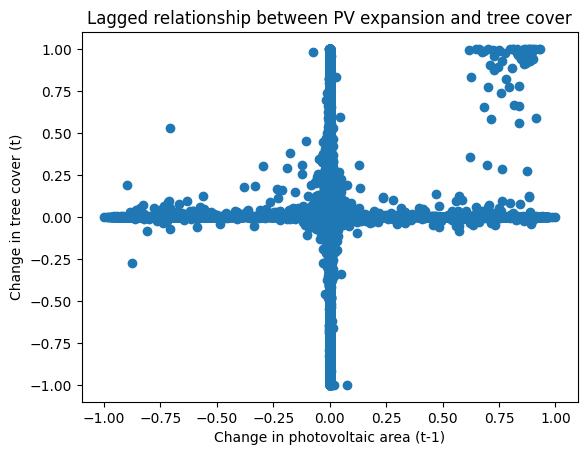

In [46]:
plt.scatter(df['delta_pv_lag1'], df['delta_tree'])
plt.xlabel('Change in photovoltaic area (t-1)')
plt.ylabel('Change in tree cover (t)')
plt.title('Lagged relationship between PV expansion and tree cover')
plt.show()

Wartość współczynnika korelacji (-0.144787) wskazuje na słabą ujemną zależność między badanymi zmiennymi. Oznacza to, że większy wzrost powierzchni instalacji PV w poprzednim roku może wiązać się z nieznacznie mniejszym przyrostem zadrzewienia w kolejnym roku. Słabą zależność potwierdza również wykres (duża zmienność oraz brak wyraźnego trendu liniowego).

In [47]:
mask = df[["delta_tree", "delta_pv_lag1"]].dropna().index
r_lag, p_lag = pearsonr(
    df.loc[mask, "delta_tree"],
    df.loc[mask, "delta_pv_lag1"]
)

r_lag, p_lag

(np.float64(0.013733811663336086), np.float64(1.7986066524285612e-05))

Występuje słaba, ale statystycznie istotna (p<0.05) ujemna korelacja pomiędzy zmianami powierzchni PV a zmianami zadrzewienia.

In [48]:
X = df['delta_pv_lag1']
y = df['delta_tree']

mask = X.notna() & y.notna()

X = sm.add_constant(X[mask])
y = y[mask]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             delta_tree   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     18.39
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           1.80e-05
Time:                        01:12:54   Log-Likelihood:                 38388.
No. Observations:               97500   AIC:                        -7.677e+04
Df Residuals:                   97498   BIC:                        -7.675e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0252      0.001     48.237

Na podstawie liniowego model regresji z jednorocznym opóźnieniem zmiennej, widać słabą, ale statystycznie istotną ujemną zależność pomiędzy przyrostem powierzchni instalacji PV w roku poprzednim a zmianą zadrzewienia w roku następnym. Wskazuje na to coef =-2.4042 oraz p=0.041. Niski współczynnik determinacji (0.021) sugeruje, że zmiany zadrzewienia są w niewielkim stopniu wyjaśniane przez zmienną PV i mogą mieć na nie wpływ inne czynniki.

Uzyskane wyniki wskazują na istnienie słabej, lecz statystycznie istotnej zależności pomiędzy budowaniem instalacji fotowoltaicznych a zmianami zadrzewienia. Siła tej zależności jest niewielka, jej kierunek jest zgodny z hipotezą o potencjalnym konflikcie pomiędzy rozwojem PV a terenami zielonymi.